In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import logomaker as lm
import os
import matplotlib as mpl
import matplotlib.colors as colors
from matplotlib.patches import Rectangle

Matplotlib is building the font cache; this may take a moment.


In [3]:
working_dir = "./exemplar_figures/"

In [4]:
def global_fp(sub_df):
    tot = sum(sub_df["n_reads"].to_list())
    mod = int(sum([fp * n_reads for fp, n_reads in zip(sub_df["false_positive"].to_list(), 
                                                       sub_df["n_reads"].to_list())]))
    return mod / tot

In [7]:
ninemer_df = pd.read_csv("../error_tables/GM12878_genomic_IVT_refmatch_9mer_all_threshold.dorado_1.0.tsv.gz", sep="\t", usecols = [0, 1, 2, 32])
ninemer_df.columns = ["mer", "mod", "false_positive", "n_reads"]
ninemer_df["mer"] = [x.replace('T', 'U') for x in ninemer_df["mer"].to_list()]

In [8]:
ninemer_df["n_reads"].min()

218

In [9]:
psi_global = global_fp(ninemer_df[ninemer_df["mod"] == "17802"])
m6a_global = global_fp(ninemer_df[ninemer_df["mod"] == "a"])
ino_global = global_fp(ninemer_df[ninemer_df["mod"] == "17596"])
m5c_global = global_fp(ninemer_df[ninemer_df["mod"] == "m"])
g_2ome_global = global_fp(ninemer_df[ninemer_df["mod"] == "19229"])
a_2ome_global = global_fp(ninemer_df[ninemer_df["mod"] == "69426"])
c_2ome_global = global_fp(ninemer_df[ninemer_df["mod"] == "19228"])
u_2ome_global = global_fp(ninemer_df[ninemer_df["mod"] == "19227"])

print(f"Psi Global: {psi_global}")
print(f"m6A Global: {m6a_global}")
print(f"Inosine Global: {ino_global}")
print(f"m5c Global: {m5c_global}")
print(f"2'Ome G Global: {g_2ome_global}")
print(f"2'Ome A Global: {a_2ome_global}")
print(f"2'Ome C Global: {c_2ome_global}")
print(f"2'Ome U Global: {u_2ome_global}")

Psi Global: 0.0035928045493328928
m6A Global: 0.005405739436193042
Inosine Global: 0.003441985661878273
m5c Global: 0.006687308980335273
2'Ome G Global: 0.008565134911200534
2'Ome A Global: 0.001557037780166132
2'Ome C Global: 0.002960618932582723
2'Ome U Global: 0.0051549509450854285


/var/folders/sf/wj5nsbs11gjcmpmdx0vfm2c80000gn/T/ipykernel_93423/3313753998.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df["x_axis"] = [i for i in range(sub_df.shape[0])]
/var/folders/sf/wj5nsbs11gjcmpmdx0vfm2c80000gn/T/ipykernel_93423/3313753998.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df["x_axis"] = [i for i in range(sub_df.shape[0])]
/var/folders/sf/wj5nsbs11gjcmpmdx0vfm2c80000gn/T/ipykernel_93423/3313753998.py:13: SettingWithCopyWarning: 
A value is trying to be set on a cop

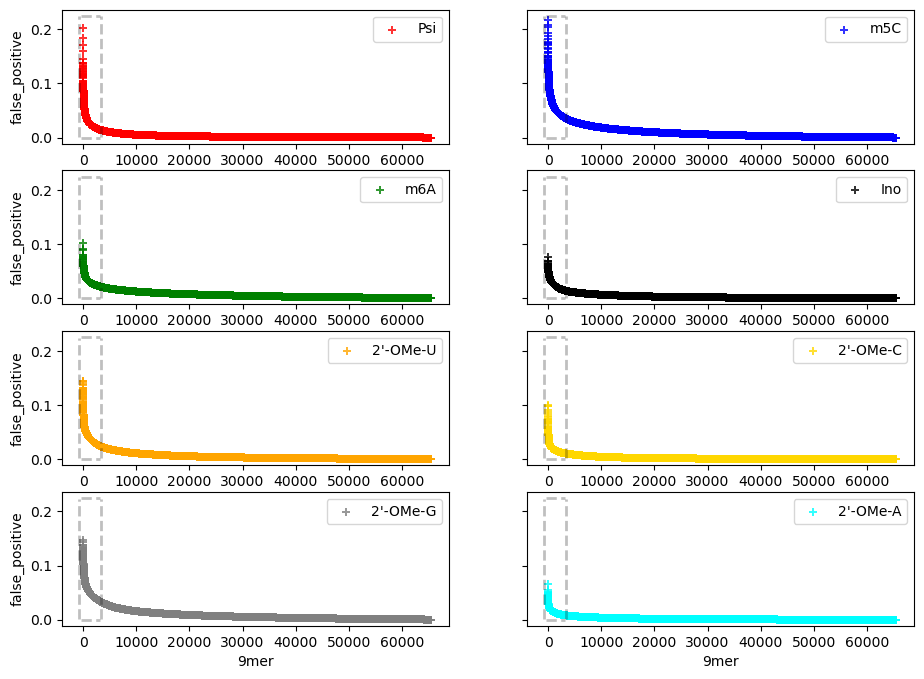

In [11]:
mod_color = {'17802':'r', 'm':'b', 'a':'g', '17596':'k', '19227':'orange', '19228':'gold', '19229':'grey', '69426':'cyan'}
mod_marker = {'17802':'P', 'm':'P', 'a':'P', '17596':'P', '19227':'P', '19228':'P', '19229':'P', '69426':'P'}
mod_label = {'17802':'Psi', 'm':'m5C', 'a':'m6A', '17596':'Ino', '19227':"2'-OMe-U", '19228':"2'-OMe-C", '19229':"2'-OMe-G", '69426':"2'-OMe-A"}
mods = ['17802', 'm', 'a', '17596', '19227', '19228', '19229', '69426']
fig, ax = plt.subplots(4, 2, sharey = True)
fig.set_figwidth(11)
fig.set_figheight(8)
for i in range(4):
    for j in range(2):
        mod_index = i * 2 + j
        mod = mods[mod_index]
        sub_df = ninemer_df[ninemer_df["mod"] == mod]
        sub_df["x_axis"] = [i for i in range(sub_df.shape[0])]
        ax[i][j].axvline(x=3277, ymax = 0.95, ymin=0.05, linewidth=2, linestyle="--", alpha = 0.25, color='k')
        ax[i][j].axvline(x=-750, ymax = 0.95, ymin=0.05, linewidth=2, linestyle="--", alpha=0.25, color='k')
        ax[i][j].axhline(y=0.225, xmin=0.05, xmax=0.1, linestyle="--", alpha=0.25, color='k', linewidth=2)
        ax[i][j].axhline(y=0.0, xmin=0.05, xmax=0.1, linestyle="--", alpha=0.25, color='k', linewidth=2)

        sns.scatterplot(data=sub_df, x = "x_axis", y = "false_positive", label=mod_label[mod], c=mod_color[mod], marker = mod_marker[mod], linewidth=0, alpha = 0.8, ax = ax[i][j])
        ax[i][j].set_xlabel('9mer')
fig.get_figure().savefig(os.path.join(working_dir, "False_positive.png"), dpi=600)

In [12]:
for mod in ['17802', 'm', 'a', '17596', '19227', '19228', '19229', '69426']:
    sub_df = ninemer_df[(ninemer_df["mod"] == mod)]
    for percentile, divisor in zip([0.01, 0.1, 0.5, 1, 2, 3, 4, 5],
                                   [10000, 1000, 200, 100, 50, 33.333333, 25, 20]):
        print(f"Number of observations = {sub_df[:int(sub_df.shape[0]/divisor)].shape[0]}")
        print(f"For {mod} top {percentile}% fp={round(sub_df[:int(sub_df.shape[0]/divisor)].tail(n=1)['false_positive'].to_list()[0], 4)}")

Number of observations = 6
For 17802 top 0.01% fp=0.1385
Number of observations = 65
For 17802 top 0.1% fp=0.0875
Number of observations = 327
For 17802 top 0.5% fp=0.047
Number of observations = 655
For 17802 top 1% fp=0.0349
Number of observations = 1310
For 17802 top 2% fp=0.0248
Number of observations = 1966
For 17802 top 3% fp=0.0196
Number of observations = 2621
For 17802 top 4% fp=0.0163
Number of observations = 3276
For 17802 top 5% fp=0.0141
Number of observations = 6
For m top 0.01% fp=0.1814
Number of observations = 65
For m top 0.1% fp=0.1225
Number of observations = 327
For m top 0.5% fp=0.0838
Number of observations = 655
For m top 1% fp=0.0677
Number of observations = 1310
For m top 2% fp=0.0529
Number of observations = 1966
For m top 3% fp=0.0446
Number of observations = 2621
For m top 4% fp=0.0396
Number of observations = 3276
For m top 5% fp=0.0357
Number of observations = 6
For a top 0.01% fp=0.077
Number of observations = 65
For a top 0.1% fp=0.0594
Number of observ

          mer    mod  false_positive  n_reads
3   CCCUUUAGG  17802        0.202749    67004
6   CCCUUUUGG  17802        0.183474   103519
13  CCCUUUAGA  17802        0.170527    88854
16  CGCUUUAGG  17802        0.159783     9225
28  GACUUUAGG  17802        0.145478    83944
             mer    mod  false_positive  n_reads
49891  AGCUUUGUA  17802        0.014085   144049
49892  CACCUUCCG  17802        0.014085    26270
49898  GUUUUGCCC  17802        0.014083    84500
49903  GACCUUGGA  17802        0.014082   134502
49919  UCGAUUGAG  17802        0.014079    12643
         mer mod  false_positive  n_reads
0  GACGCAGGG   m        0.217449    23233
1  GACGCAGGA   m        0.207435    29455
2  AGCUCGAAC   m        0.204819    24612
4  GACGCAGAA   m        0.194121    38270
5  GACGCGGGG   m        0.187183     9456
            mer mod  false_positive  n_reads
9343  GGCUCGACC   m        0.035678     5886
9345  GGGUCGUGC   m        0.035676     9334
9350  GAAUCACCU   m        0.035667   17957

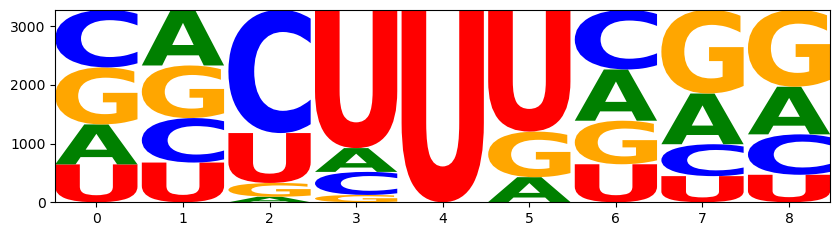

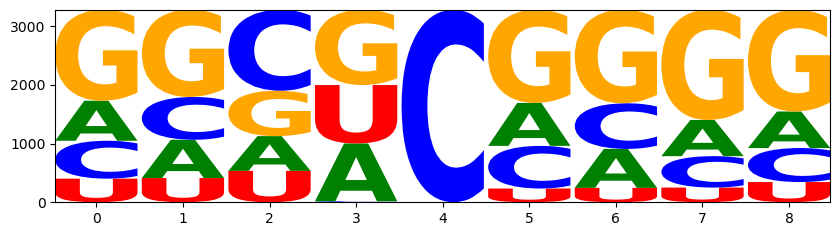

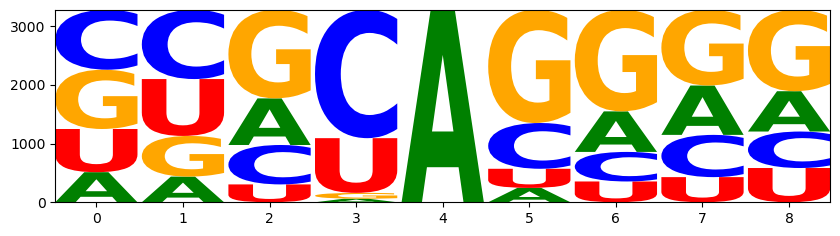

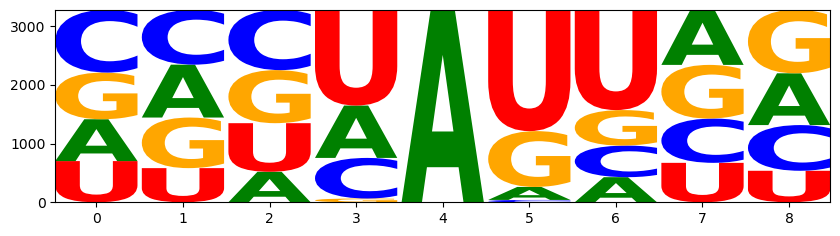

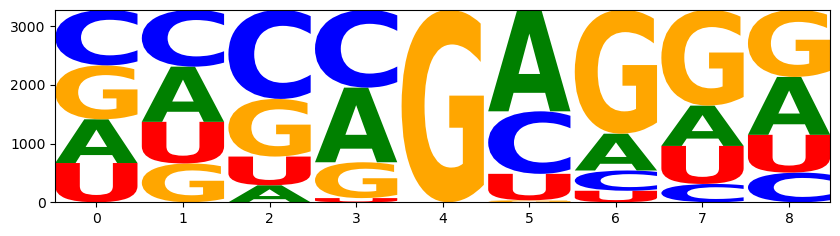

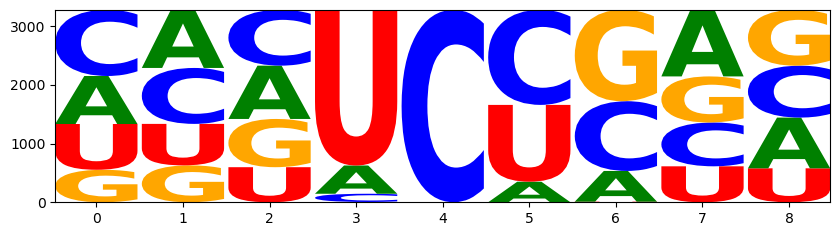

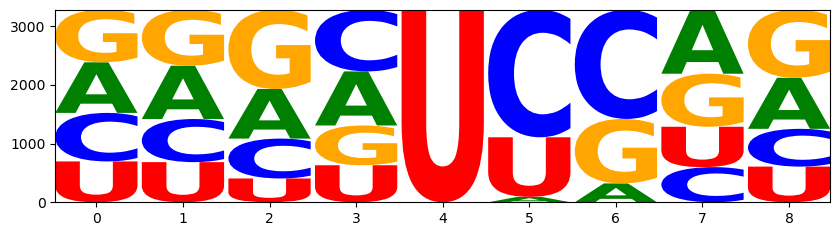

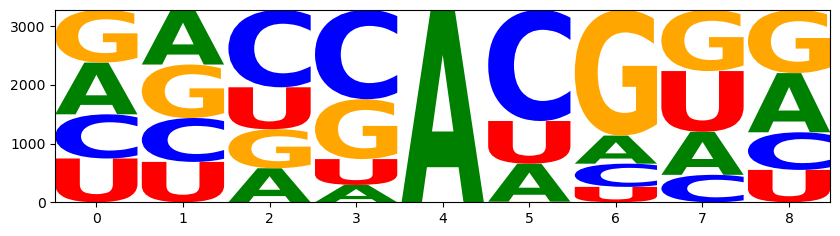

In [14]:
high_psi = ninemer_df[(ninemer_df["mod"]=='17802')]
high_psi = high_psi[:int(high_psi.shape[0]/20)]
print(high_psi.head())
print(high_psi.tail())
counts_mat = lm.alignment_to_matrix(high_psi["mer"].to_list())
lm.Logo(counts_mat)
plt.savefig(os.path.join(working_dir, "Psi_top5_percentile_seqlogo.pdf"), dpi=600)

high_m5c = ninemer_df[(ninemer_df["mod"]=='m')]
high_m5c = high_m5c[:int(high_m5c.shape[0]/20)]
print(high_m5c.head())
print(high_m5c.tail())
counts_mat = lm.alignment_to_matrix(high_m5c["mer"].to_list())
counts_mat.head()
lm.Logo(counts_mat)
plt.savefig(os.path.join(working_dir, "m5C_top5_percentile_seqlogo.pdf"), dpi=600)

high_m6a = ninemer_df[(ninemer_df["mod"]=='a')]
high_m6a = high_m6a[:int(high_m6a.shape[0]/20)]
print(high_m6a.head())
print(high_m6a.tail())
counts_mat = lm.alignment_to_matrix(high_m6a["mer"].to_list())
counts_mat.head()
lm.Logo(counts_mat)
plt.savefig(os.path.join(working_dir, "m6A_top5_percentile_seqlogo.pdf"), dpi=600)

high_ino = ninemer_df[(ninemer_df["mod"]=='17596')]
high_ino = high_ino[:int(high_ino.shape[0]/20)]
print(high_ino.head())
print(high_ino.tail())
counts_mat = lm.alignment_to_matrix(high_ino["mer"].to_list())
counts_mat.head()
lm.Logo(counts_mat)
plt.savefig(os.path.join(working_dir, "Ino_top5_percentile_seqlogo.pdf"), dpi=600)

high_2OG = ninemer_df[(ninemer_df["mod"]=='19229')]
high_2OG = high_2OG[:int(high_2OG.shape[0]/20)]
print(high_2OG.head())
print(high_2OG.tail())
counts_mat = lm.alignment_to_matrix(high_2OG["mer"].to_list())
lm.Logo(counts_mat)
plt.savefig(os.path.join(working_dir, "G-2'OMe_top5_percentile_seqlogo.pdf"), dpi=600)

high_2OC = ninemer_df[(ninemer_df["mod"]=='19228')]
high_2OC = high_2OC[:int(high_2OC.shape[0]/20)]
print(high_2OC.head())
print(high_2OC.tail())
counts_mat = lm.alignment_to_matrix(high_2OC["mer"].to_list())
lm.Logo(counts_mat)
plt.savefig(os.path.join(working_dir, "C-2'OMe_top5_percentile_seqlogo.pdf"), dpi=600)

high_2OU = ninemer_df[(ninemer_df["mod"]=='19227')]
high_2OU = high_2OU[:int(high_2OU.shape[0]/20)]
print(high_2OU.head())
print(high_2OU.tail())
counts_mat = lm.alignment_to_matrix(high_2OU["mer"].to_list())
lm.Logo(counts_mat)
plt.savefig(os.path.join(working_dir, "U-2'OMe_top5_percentile_seqlogo.pdf"), dpi=600)

high_2OA = ninemer_df[(ninemer_df["mod"]=='69426')]
high_2OA = high_2OA[:int(high_2OA.shape[0]/20)]
print(high_2OA.head())
print(high_2OA.tail())
counts_mat = lm.alignment_to_matrix(high_2OA["mer"].to_list())
lm.Logo(counts_mat)
plt.savefig(os.path.join(working_dir, "A-2'OMe_top5_percentile_seqlogo.pdf"), dpi=600)